In [45]:
import numpy as np
import pandas as pd
import os
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


ModuleNotFoundError: No module named 'seaborn'

In [31]:
def readData(datafile, convert=False, export=False):
    # get the current directory: directory name for the abs path of the curr file
    dirpath = os.getcwd()
    abspath = dirpath + "\\" + datafile + ".csv"

    # read data into a pandas dataframe. data file is comma separated so use read_csv
    df = pd.read_csv(abspath)

    # convert categorical data to numerical if convert is true
    if (convert):
        mapGender = {'Male':0, 'Female':1, 'Other':2}
        mapMarital = {'Single':0, 'Divorced':1, 'Married':2}
        mapEdu = {'High School':0, 'Bachelor':1, 'Master':2, 'PhD':3}
        mapEmpl = {'Student':0, 'Unemployed':1, 'Employed':2, 'Self-Employed':3}
        maps = [mapGender, mapMarital, mapEdu, mapEmpl]

        idx=0
        for feat in df.columns:
            if df[feat].dtype == 'string':
                df[feat] = df[feat].map(maps[idx])
                idx += 1
        
        if (export):
            convname = dirpath + "\\" + datafile + "_conv.csv"
            df.to_csv(convname)
    
        
    return df

[[0.0000e+00 5.6000e+01 2.0000e+00 ... 1.0000e+00 1.0000e+00 1.0000e+00]
 [1.0000e+00 4.7000e+01 0.0000e+00 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.0000e+00 5.6000e+01 1.0000e+00 ... 1.0000e+00 1.0000e+00 2.0000e+00]
 ...
 [2.4997e+04 3.5000e+01 1.0000e+00 ... 0.0000e+00 1.0000e+00 2.0000e+00]
 [2.4998e+04 4.4000e+01 0.0000e+00 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [2.4999e+04 1.9000e+01 0.0000e+00 ... 0.0000e+00 1.0000e+00 1.0000e+00]]


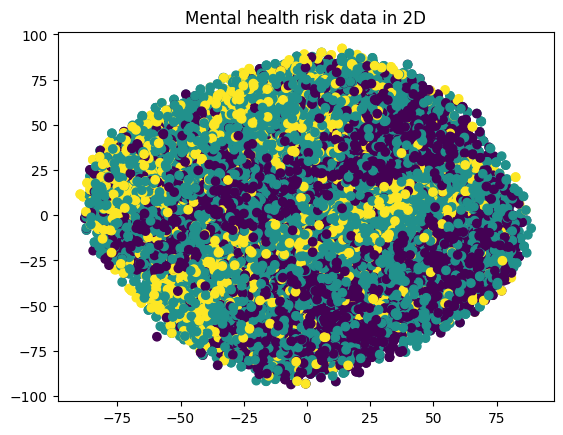

In [48]:
filename = "mental_health_risk_dataset_conv"
data = readData(filename)

data = data.to_numpy()
print(data)

x = data[:, 0:-1]       # data is all features
target = data[:,-1]     # target is mental_health_risk

scaler = StandardScaler()
xscaled = scaler.fit_transform(x)

ndims = 2 # dims of the embedded space
tsne = TSNE(ndims)
result = tsne.fit_transform(xscaled)
result_df = pd.DataFrame({'TSNE_col1': result[:,0], 'TSNE_col2': result[:,1], 'MentalHealthRisk' : target})
fig, ax = plt.subplots()
ax.scatter(x=result_df['TSNE_col1'], y=result_df['TSNE_col2'], c=result_df['MentalHealthRisk'])
plt.title("Mental health risk data in 2D")
plt.show()


